# RRA rank distributions by dataset

This notebook visualizes **robust positive** (high-rank) and **robust negative** (low-rank) samples from `sample_rra_consensus.csv`.


In [92]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Resolve repo root (look for configs/analysis/embeddings_probe_runs.toml)
root = Path.cwd().resolve()
marker = Path('configs/analysis/embeddings_probe_runs.toml')
if not (root / marker).exists():
    for parent in root.parents:
        if (parent / marker).exists():
            root = parent
            break
csv_path = root / 'analysis/embeddings_probe/ranking_agreement/test/sample_rra_consensus.csv'

df = pd.read_csv(csv_path)

# Robust positives and negatives
pos = df[df['rra_rank_pos'].notna()].copy()
neg = df[df['rra_rank_neg'].notna()].copy()

# Convert ranks to percentiles (1 = best)
N = len(df)
pos['rank_pct'] = 1.0 - (pos['rra_rank_pos'] - 1) / (N - 1)
# rra_rank_neg is inverted back to original direction; undo for low-rank percentile
neg['rank_pct_low'] = (N - neg['rra_rank_neg']) / (N - 1)

print('Total samples:', N)
print('Robust positives:', len(pos))
print('Robust negatives:', len(neg))


Total samples: 73236
Robust positives: 7411
Robust negatives: 11456


/tmp/ipykernel_216339/984861568.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


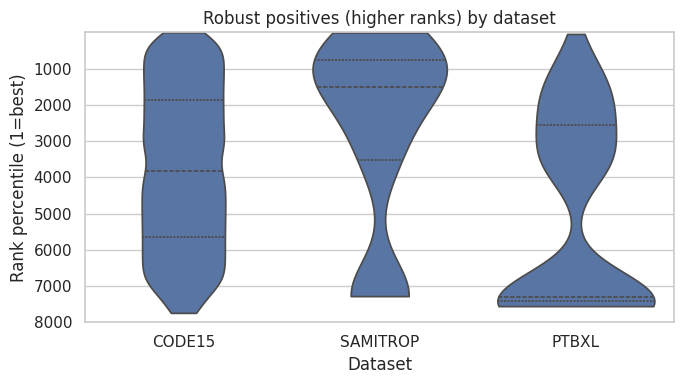

In [93]:
# Higher ranks (robust positives)
sns.set_theme(style='whitegrid')

plt.figure(figsize=(7, 4))
sns.violinplot(data=pos, x='dataset_source', y='rra_rank_pos', inner='quartile', cut=0)
plt.title('Robust positives (higher ranks) by dataset')
plt.ylabel('Rank percentile (1=best)')
plt.ylim(8000,1)  # reverse y-axis
plt.xlabel('Dataset')
plt.tight_layout()
out_path = root / 'analysis/embeddings_probe/ranking_agreement/test/plots/robust_pos_dataset.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=200)
plt.show()


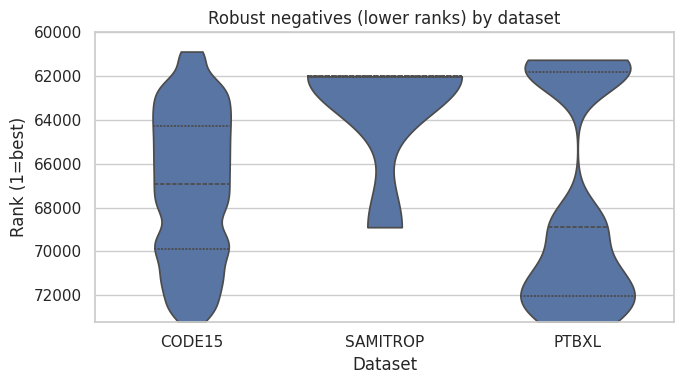

In [94]:
# Lower ranks (robust negatives)
plt.figure(figsize=(7, 4))
sns.violinplot(data=neg, x='dataset_source', y='rra_rank_neg', inner='quartile', cut=0)
plt.title('Robust negatives (lower ranks) by dataset')
plt.ylabel('Rank (1=best)')
plt.xlabel('Dataset')
plt.ylim(N, 60000)  # reverse y-axis and start at N (73236)
plt.tight_layout()
out_path = root / 'analysis/embeddings_probe/ranking_agreement/test/plots/robust_neg_dataset.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=200)
plt.show()


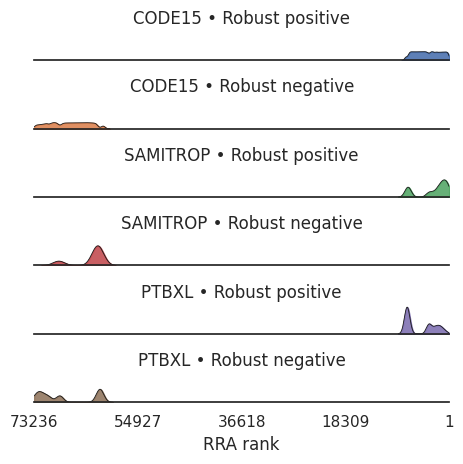

In [95]:
# Ridgeline plot: dataset x robust set (pos/neg)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ridge_df = pd.concat([
    pos.assign(group='Robust positive').rename(columns={'rra_rank_pos': 'rank'}),
    neg.assign(group='Robust negative').rename(columns={'rra_rank_neg': 'rank'})
], ignore_index=True)

ridge_df = ridge_df[['dataset_source','group','rank']].dropna()
ridge_df['dataset_group'] = ridge_df['dataset_source'] + ' • ' + ridge_df['group']

# Order: CODE15 pos/neg, SAMITROP pos/neg, PTBXL pos/neg
order = [
    'CODE15 • Robust positive', 'CODE15 • Robust negative',
    'SAMITROP • Robust positive', 'SAMITROP • Robust negative',
    'PTBXL • Robust positive', 'PTBXL • Robust negative',
]
ridge_df['dataset_group'] = pd.Categorical(ridge_df['dataset_group'], categories=order, ordered=True)

sns.set_theme(style='white', rc={'axes.facecolor': (0,0,0,0)})
g = sns.FacetGrid(
    ridge_df, row='dataset_group', hue='dataset_group', aspect=6, height=0.8,
    sharex=True, sharey=True
)
g.map(sns.kdeplot, 'rank', bw_adjust=0.6, clip=(1, N), fill=True, alpha=0.9)
g.map(sns.kdeplot, 'rank', bw_adjust=0.6, clip=(1, N), color='k', lw=0.6)
g.set_titles(row_template='{row_name}')
g.set(xlim=(N, 0))
g.set_xlabels('RRA rank')
g.set_ylabels('')
g.despine(left=True)

# only 5 x ticks
ticks = np.linspace(1, N, 5).astype(int)
for ax in g.axes.flatten():
    ax.set_yticks([])
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])

plt.tight_layout()
out_path = root / 'analysis/embeddings_probe/ranking_agreement/test/plots/rra_ridgeline.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=300)
plt.show()


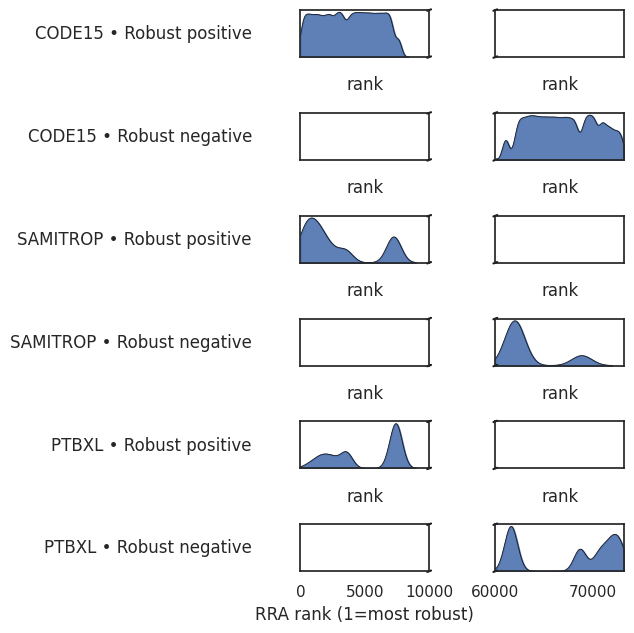

In [96]:
# Ridgeline with broken x-axis (skip mid ranks)
import seaborn as sns
import matplotlib.pyplot as plt

ridge_df = pd.concat([
    pos.assign(group='Robust positive').rename(columns={'rra_rank_pos': 'rank'}),
    neg.assign(group='Robust negative').rename(columns={'rra_rank_neg': 'rank'})
], ignore_index=True)
ridge_df = ridge_df[['dataset_source','group','rank']].dropna()
ridge_df['dataset_group'] = ridge_df['dataset_source'] + ' • ' + ridge_df['group']
order = [
    'CODE15 • Robust positive', 'CODE15 • Robust negative',
    'SAMITROP • Robust positive', 'SAMITROP • Robust negative',
    'PTBXL • Robust positive', 'PTBXL • Robust negative',
]
ridge_df['dataset_group'] = pd.Categorical(ridge_df['dataset_group'], categories=order, ordered=True)

# axis break ranges
left = (0, 10000)
right = (60000, N)

sns.set_theme(style='white', rc={'axes.facecolor': (0,0,0,0)})
fig, axes = plt.subplots(nrows=len(order), ncols=2, figsize=(6.5, 6.5), sharey='row')

for i, grp in enumerate(order):
    ax_l, ax_r = axes[i]
    sub = ridge_df[ridge_df['dataset_group'] == grp]
    sns.kdeplot(sub['rank'], ax=ax_l, bw_adjust=0.6, clip=left, fill=True, alpha=0.9)
    sns.kdeplot(sub['rank'], ax=ax_l, bw_adjust=0.6, clip=left, color='k', lw=0.6)
    sns.kdeplot(sub['rank'], ax=ax_r, bw_adjust=0.6, clip=right, fill=True, alpha=0.9)
    sns.kdeplot(sub['rank'], ax=ax_r, bw_adjust=0.6, clip=right, color='k', lw=0.6)
    ax_l.set_xlim(left)
    ax_r.set_xlim(right)
    ax_l.set_yticks([])
    ax_r.set_yticks([])
    ax_l.set_ylabel(grp, rotation=0, ha='right', va='center', labelpad=35)
    # break marks
    d = .015
    kwargs = dict(transform=ax_l.transAxes, color='k', clip_on=False)
    ax_l.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax_l.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
    kwargs.update(transform=ax_r.transAxes)
    ax_r.plot((-d, +d), (-d, +d), **kwargs)
    ax_r.plot((-d, +d), (1-d, 1+d), **kwargs)

for ax in axes[:-1, :].flat:
    ax.set_xticklabels([])

axes[-1,0].set_xlabel('RRA rank (1=most robust)')
axes[-1,1].set_xlabel('')

plt.tight_layout()
out_path = root / 'analysis/embeddings_probe/ranking_agreement/test/plots/rra_ridgeline_broken.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=200)
plt.show()


In [97]:
# Kruskal–Wallis tests across datasets (robust positives / negatives)
from scipy.stats import kruskal

def _kw_test(df_sub, value_col):
    groups = []
    labels = []
    for ds in ['CODE15', 'SAMITROP', 'PTBXL']:
        vals = df_sub[df_sub['dataset_source'] == ds][value_col].dropna().to_numpy()
        if len(vals) == 0:
            continue
        groups.append(vals)
        labels.append(ds)
    stat, p = kruskal(*groups)
    return labels, stat, p

labels_pos, H_pos, p_pos = _kw_test(pos, 'rra_rank_pos')
labels_neg, H_neg, p_neg = _kw_test(neg, 'rra_rank_neg')

print('Kruskal–Wallis (robust positives):')
print('  groups:', labels_pos)
print('  H =', H_pos, 'p =', p_pos)

print('Kruskal–Wallis (robust negatives):')
print('  groups:', labels_neg)
print('  H =', H_neg, 'p =', p_neg)


Kruskal–Wallis (robust positives):
  groups: ['CODE15', 'SAMITROP', 'PTBXL']
  H = 147.22323850950124 p = 1.0736925846248755e-32
Kruskal–Wallis (robust negatives):
  groups: ['CODE15', 'SAMITROP', 'PTBXL']
  H = 90.11818613093783 p = 2.6982645157840343e-20
